Saved: lc-pom/Interpolated_Director_Field/rotated_90_ribbon_L_201_r_40_re_1p0um.txt


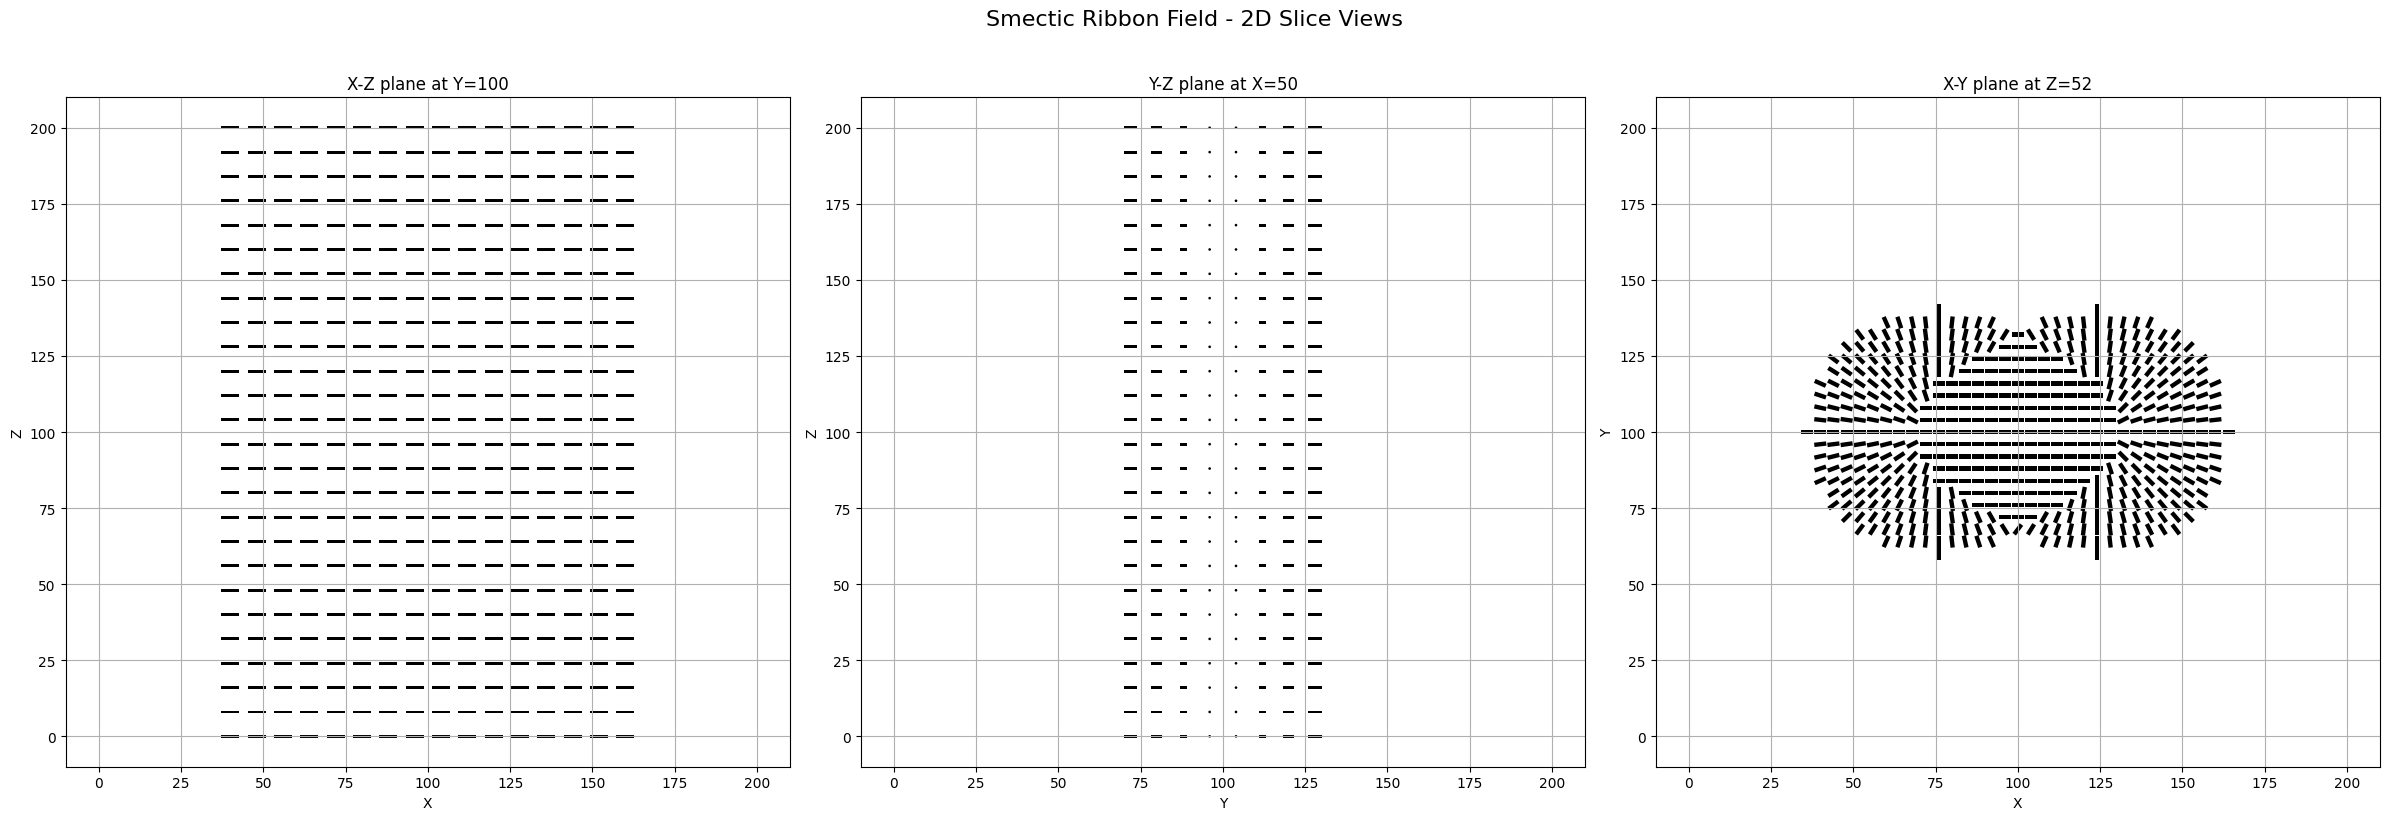

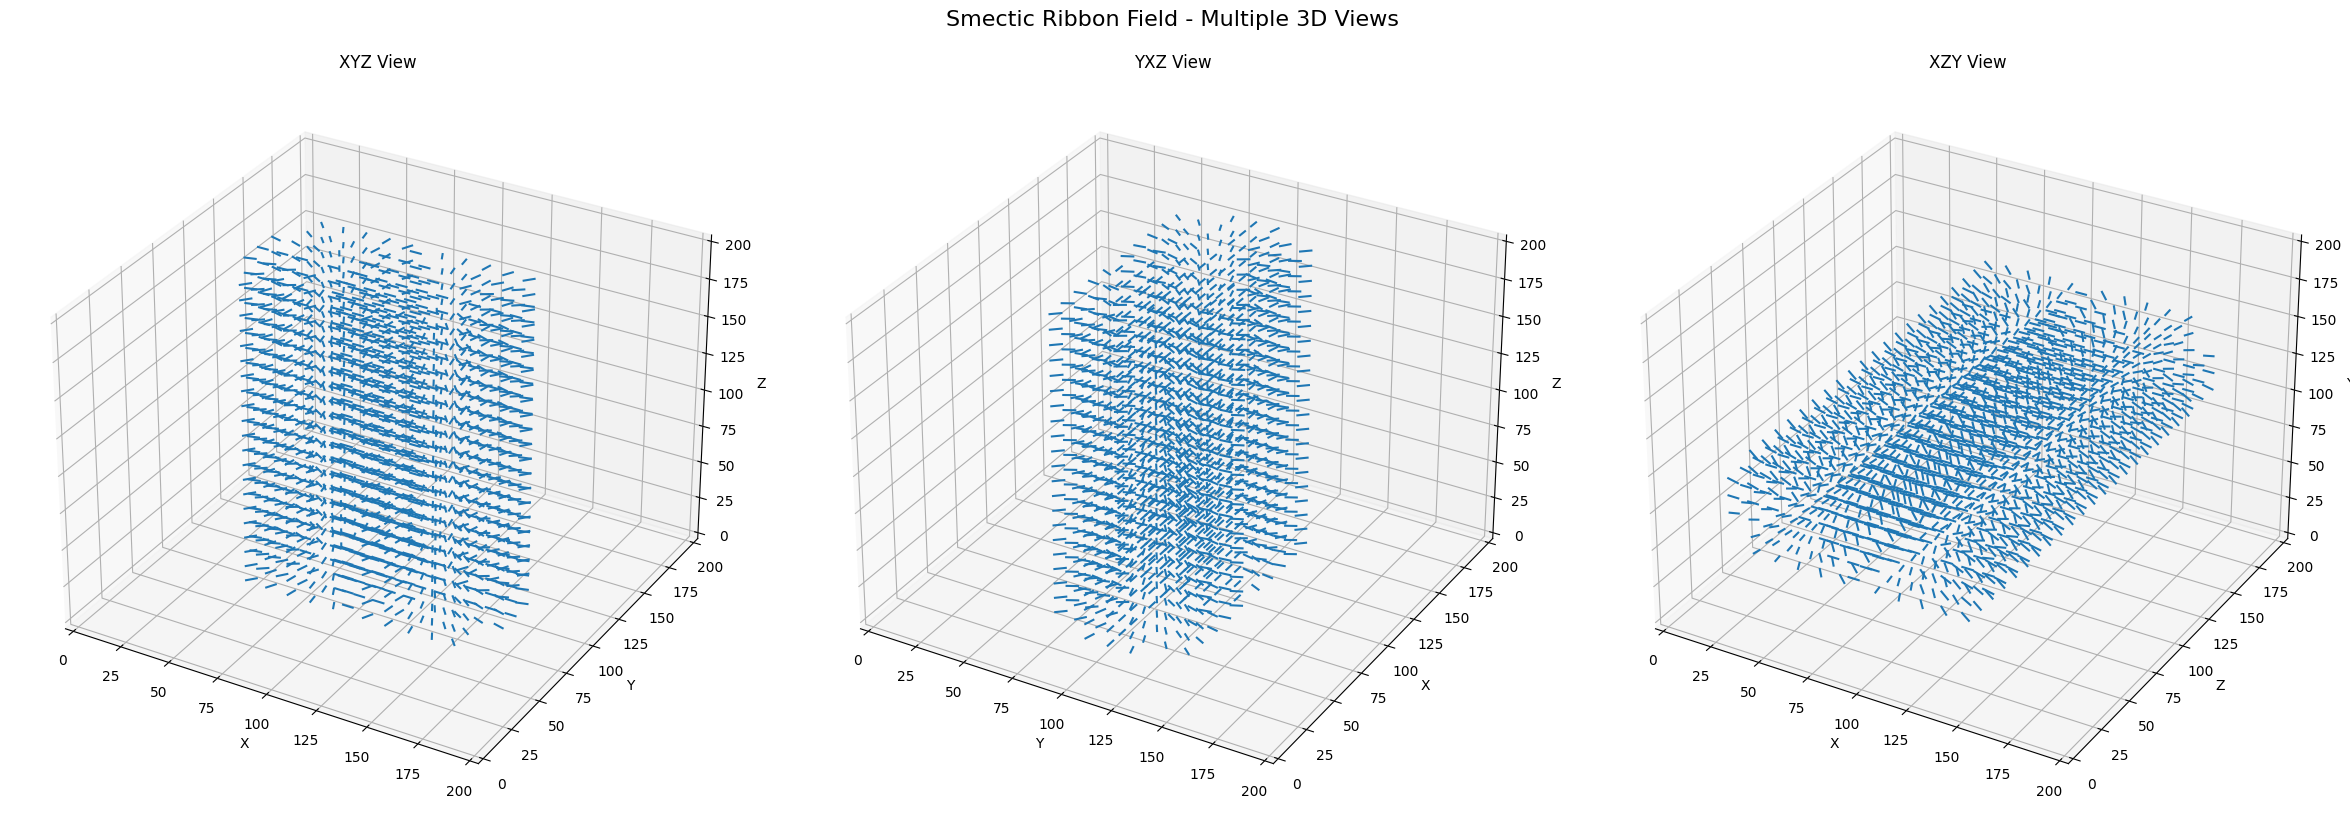

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform


def create_director_cyl_w_parabola_x_plus(X, Y, Z, nx, ny, nz, Cx, Cy, Cz,
                                        Cx_mid, Cy_mid, Cz_mid, r, h, f):
    # Convert existing director arrays to float64 for consistent precision
    nx = nx.astype(np.float64)
    ny = ny.astype(np.float64)
    nz = nz.astype(np.float64)

    # Compute radial distance of each (X,Y) point from cylinder axis center
    distances_squared = (X - Cx) ** 2 + (Y - Cy) ** 2
    distances = np.sqrt(distances_squared)

    # Create mask for points inside the finite cylinder along Z
    mask_cylinder = (
        (distances <= r) &  # within radius
        (Z >= (Cz - h / 2)) &  # above bottom cap
        (Z <= (Cz + h / 2))    # below top cap
    )

    # Replace very small distances to avoid division by zero later
    distances = np.where(distances < 1e-6, 1e-6, distances)

    # Compute angle to align X-axis with direction toward midpoint
    theta = np.arctan2(Cy_mid - Cy, Cx_mid - Cx)

    # Rotate grid points so that parabola opening aligns with X_rot axis
    X_rot = np.cos(theta) * (X - Cx) + np.sin(theta) * (Y - Cy)
    Y_rot = -np.sin(theta) * (X - Cx) + np.cos(theta) * (Y - Cy)

    # Parabolic region condition in rotated coordinates
    parabola_mask = (4 * f * (X_rot + f)) >= (Y_rot ** 2)

    # Define two regions: inside parabola and outside \// cylinder
    inside_parabola = mask_cylinder & parabola_mask
    outside_parabola = mask_cylinder & ~parabola_mask

    # Compute normalized vector pointing from cylinder center to midpoint
    direction_vector = np.array([Cx_mid - Cx, Cy_mid - Cy, Cz_mid - Cz], dtype=np.float64)
    direction_vector_normalized = direction_vector / np.linalg.norm(direction_vector)

    # Assign this direction within the parabolic region
    nx[inside_parabola], ny[inside_parabola], nz[inside_parabola] = (
        direction_vector_normalized
    )

    # For outside region: compute normalized radial director in XY-plane
    x_val = (X[outside_parabola] - Cx) / distances[outside_parabola]
    y_val = (Y[outside_parabola] - Cy) / distances[outside_parabola]

    # Z-component is zero for purely radial in XY-plane
    nx[outside_parabola], ny[outside_parabola], nz[outside_parabola] = x_val, y_val, 0

    return nx, ny, nz


def create_director_cyl_w_parabola_x_minus(X, Y, Z, nx, ny, nz, Cx, Cy, Cz,
                                         Cx_mid, Cy_mid, Cz_mid, r, h, f):
    # Convert arrays to float64 for numerical consistency
    nx = nx.astype(np.float64)
    ny = ny.astype(np.float64)
    nz = nz.astype(np.float64)

    # Compute distance from cylinder axis center in XY-plane
    distances_squared = (X - Cx) ** 2 + (Y - Cy) ** 2
    distances = np.sqrt(distances_squared)

    # Mask for points within cylindrical volume along Z-axis
    mask_cylinder = (
        (distances <= r) &
        (Z >= (Cz - h / 2)) &
        (Z <= (Cz + h / 2))
    )

    # Prevent division by zero on axis
    distances = np.where(distances < 1e-6, 1e-6, distances)

    # Calculate alignment angle to parabola midpoint
    theta = np.arctan2(Cy_mid - Cy, Cx_mid - Cx)

    # Rotate XY grid into local parabola frame
    X_rot = np.cos(theta) * (X - Cx) + np.sin(theta) * (Y - Cy)
    Y_rot = -np.sin(theta) * (X - Cx) + np.cos(theta) * (Y - Cy)

    # Identify parabolic interior in rotated frame
    parabola_mask = (4 * f * (X_rot + f)) >= (Y_rot ** 2)

    # Combine cylinder and parabola masks
    inside_parabola = mask_cylinder & parabola_mask
    outside_parabola = mask_cylinder & ~parabola_mask

    # Vector from axis center to midpoint (for parabolic region)
    direction_vector = np.array([Cx_mid - Cx, Cy_mid - Cy, Cz_mid - Cz], dtype=np.float64)
    direction_vector_normalized = direction_vector / np.linalg.norm(direction_vector)

    # Assign midpoint-directed orientation inside parabola
    nx[inside_parabola], ny[inside_parabola], nz[inside_parabola] = (
        direction_vector_normalized
    )

    # Compute radial XY orientation outside parabola
    x_val = (X[outside_parabola] - Cx) / distances[outside_parabola]
    y_val = (Y[outside_parabola] - Cy) / distances[outside_parabola]
    nx[outside_parabola], ny[outside_parabola], nz[outside_parabola] = x_val, y_val, 0

    return nx, ny, nz


def create_double_parabola_cylinders_general(X, Y, Z, nx, ny, nz,
                                              center, r, h, distance,
                                              theta_degrees, f):
    """
    Build two cylinders separated in X, each with parabolic director alignment,
    rotated by theta_degrees around the Z-axis while maintaining midpoint.
    """
    # Convert degrees to radians for rotation
    angle = np.radians(theta_degrees)

    Cx, Cy, Cz = center
    # Define X-centers of the two cylinders around midpoint
    Cx1 = Cx - distance / 2  # left cylinder center
    Cx2 = Cx + distance / 2  # right cylinder center

    # Midpoint between cylinder centers in XY-plane
    Cx_mid = (Cx1 + Cx2) / 2
    Cy_mid = Cy  # Y-midpoint unchanged

    # Translate local centers so midpoint maps to origin
    Cx1_t, Cy1_t = Cx1 - Cx_mid, Cy_mid - Cy_mid
    Cx2_t, Cy2_t = Cx2 - Cx_mid, Cy_mid - Cy_mid

    # Rotate translated centers by angle around origin
    Cx1_r, Cy1_r = rotate_point(Cx1_t, Cy1_t, angle)
    Cx2_r, Cy2_r = rotate_point(Cx2_t, Cy2_t, angle)

    # Translate back from origin to actual midpoint coordinates
    Cx1_rot, Cy1_rot = Cx1_r + Cx_mid, Cy1_r + Cy_mid
    Cx2_rot, Cy2_rot = Cx2_r + Cx_mid, Cy2_r + Cy_mid

    # Create directors for each cylinder half
    nx, ny, nz = create_director_cyl_w_parabola_x_plus(
        X, Y, Z, nx, ny, nz,
        Cx1_rot, Cy1_rot, Cz,
        Cx_mid, Cy_mid, Cz,
        r, h, f
    )
    nx, ny, nz = create_director_cyl_w_parabola_x_minus(
        X, Y, Z, nx, ny, nz,
        Cx2_rot, Cy2_rot, Cz,
        Cx_mid, Cy_mid, Cz,
        r, h, f
    )

    return nx, ny, nz


def rotate_point(Cx, Cy, angle):
    """
    Rotate a 2D point (Cx,Cy) around origin by given angle (radians).
    """
    cos_t, sin_t = np.cos(angle), np.sin(angle)
    Cx_rot = cos_t * Cx - sin_t * Cy  # new X-coordinate
    Cy_rot = sin_t * Cx + cos_t * Cy  # new Y-coordinate
    return Cx_rot, Cy_rot


def rotate_coordinates(X, Y, angle):
    """Rotate entire coordinate grids by angle around origin."""
    cos_t, sin_t = np.cos(angle), np.sin(angle)
    # Apply 2D rotation formulas to grid arrays
    X_rot = cos_t * X - sin_t * Y
    Y_rot = sin_t * X + cos_t * Y
    return X_rot, Y_rot


def rotate_volume_and_vectors(nx, ny, nz, R):
    # Compute inverse for affine remapping of 3D volumes
    invR = np.linalg.inv(R)
    center = np.array(nx.shape) / 2  # volume center index
    
    def xf(arr):
        # Affine-transform each component array
        return affine_transform(
            arr,
            matrix=invR,
            offset=center - invR @ center,
            order=1,
            mode='nearest'
        )
    # Transform spatial volumes
    nxr, nyr, nzr = xf(nx), xf(ny), xf(nz)
    # Recombine and rotate vector components
    dirs = np.stack((nxr, nyr, nzr), axis=-1)
    out = dirs @ R.T
    return out[..., 0], out[..., 1], out[..., 2]


def export_directors(X, Y, Z, nx, ny, nz, dx, dy, dz, outdir, prefix):
    # Compose headers describing grid dimensions and spacing
    hdr1 = f"{X.shape[0]} {Y.shape[1]} {Z.shape[2]} {dx:.2f} {dy:.2f} {dz:.2f}"
    hdr2 = f"0 {X.shape[0]-1} 0 {Y.shape[1]-1} 0 {Z.shape[2]-1}"
    # Flatten coordinates and director fields for output
    data = np.vstack([
        X.ravel(), Y.ravel(), Z.ravel(),
        nx.ravel(), ny.ravel(), nz.ravel()
    ]).T
    path = os.path.join(outdir, f"{prefix}.txt")
    # Print path; enable writing if needed
    print(f"Saved: {path}")


def main():
    # Define grid dimensions
    Lx = Ly = Lz = 201
    # Create 3D meshgrid of indices
    X, Y, Z = np.meshgrid(
        np.arange(Lx), np.arange(Ly), np.arange(Lz), indexing='ij'
    )

    # Parameters for double-parabola cylinders
    center = (100, 100, 100)
    r = 40  # cylinder radius
    h = 320  # cylinder height
    tilda_R_not = 0.4  # shape factor
    f = (tilda_R_not * r) / 2  # parabola parameter
    d = (2 * r) * (1 - tilda_R_not)  # separation distance

    # Initialize director field arrays
    nx = np.zeros_like(X)
    ny = np.zeros_like(Y)
    nz = np.zeros_like(Z)

    # Populate base ribbon field using double parabola cylinders
    nx, ny, nz = create_double_parabola_cylinders_general(
        X, Y, Z, nx, ny, nz,
        center, r, h, d, 0, f
    )

    # Automated export for rotated fields
    r_e_values = [1.0]
    angles = [90]
    outdir = "lc-pom/Interpolated_Director_Field"
    for r_e in r_e_values:
        # Compute grid spacing from filament diameter
        dx = dy = dz = (r_e / r) * 1e6
        for ang in angles:
            # Rotation matrix about X-axis by angle
            R = np.array([
                [1, 0, 0],
                [0, np.cos(np.radians(ang)), -np.sin(np.radians(ang))],
                [0, np.sin(np.radians(ang)),  np.cos(np.radians(ang))]
            ])
            # Rotate entire volume and export
            nx_r, ny_r, nz_r = rotate_volume_and_vectors(
                nx, ny, nz, R
            )
            prefix = (
                f"rotated_{ang}_ribbon_L_{Lx}_r_{r}"
                f"_re_{str(r_e).replace('.', 'p')}um"
            )
            export_directors(
                X, Y, Z, nx_r, ny_r, nz_r,
                dx, dy, dz, outdir, prefix
            )

    # Visualization parameters for quiver plots
    scale1 = scale2 = 40; scale3 = 60
    width1 = width2 = 0.004; width3 = 0.006
    headaxislength = headlength = 0; headwidth = 1
    k1 = k2 = 8; k3 = 4
    y_display = 100; x_display = 50; z_display = 52

    # Mask out zero vectors in each plane for clean plotting
    nx_p1, nz_p1 = nx.copy(), nz.copy()
    mask1 = (nx_p1 == 0) & (nz_p1 == 0)
    nx_p1[mask1] = nz_p1[mask1] = np.nan
    ny_p2, nz_p2 = ny.copy(), nz.copy()
    mask2 = (ny_p2 == 0) & (nz_p2 == 0)
    ny_p2[mask2] = nz_p2[mask2] = np.nan
    nx_p3, ny_p3 = nx.copy(), ny.copy()
    mask3 = (nx_p3 == 0) & (ny_p3 == 0)
    nx_p3[mask3] = ny_p3[mask3] = np.nan

    # Plot 2D quiver slices for three orthogonal planes
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle('Smectic Ribbon Field - 2D Slice Views', fontsize=16, y=1.02)
    axes[0].quiver(
        X[::k1, y_display, ::k1], Z[::k1, y_display, ::k1],
        nx_p1[::k1, y_display, ::k1], nz_p1[::k1, y_display, ::k1],
        pivot='middle', scale=scale1, width=width1,
        headaxislength=headaxislength, headlength=headlength, headwidth=headwidth
    )
    axes[0].set(title=f'X-Z plane at Y={y_display}', xlabel='X', ylabel='Z'); axes[0].grid()
    axes[1].quiver(
        Y[x_display, ::k2, ::k2], Z[x_display, ::k2, ::k2],
        ny_p2[x_display, ::k2, ::k2], nz_p2[x_display, ::k2, ::k2],
        pivot='middle', scale=scale2, width=width2,
        headaxislength=headaxislength, headlength=headlength, headwidth=headwidth
    )
    axes[1].set(title=f'Y-Z plane at X={x_display}', xlabel='Y', ylabel='Z'); axes[1].grid()
    axes[2].quiver(
        X[::k3, ::k3, z_display], Y[::k3, ::k3, z_display],
        nx_p3[::k3, ::k3, z_display], ny_p3[::k3, ::k3, z_display],
        pivot='middle', scale=scale3, width=width3,
        headaxislength=headaxislength, headlength=headlength, headwidth=headwidth
    )
    axes[2].set(title=f'X-Y plane at Z={z_display}', xlabel='X', ylabel='Y'); axes[2].grid()
    plt.tight_layout(); plt.show()

    # Plot multiple 3D quiver views of ribbon field
    s = 10; length = 6; alr = 0  # sparsity, arrow length, head ratio
    fig = plt.figure(figsize=(24, 8))
    fig.suptitle('Smectic Ribbon Field - Multiple 3D Views', fontsize=16, y=1.02)
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.quiver(
        X[::s, ::s, ::s], Y[::s, ::s, ::s], Z[::s, ::s, ::s],
        nx[::s, ::s, ::s], ny[::s, ::s, ::s], nz[::s, ::s, ::s],
        length=length, arrow_length_ratio=alr
    )
    ax1.set(title='XYZ View', xlabel='X', ylabel='Y', zlabel='Z')
    ax1.set_xlim([0, Lx-1]); ax1.set_ylim([0, Ly-1]); ax1.set_zlim([0, Lz-1])
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.quiver(
        Y[::s, ::s, ::s], X[::s, ::s, ::s], Z[::s, ::s, ::s],
        ny[::s, ::s, ::s], nx[::s, ::s, ::s], nz[::s, ::s, ::s],
        length=length, arrow_length_ratio=alr
    )
    ax2.set(title='YXZ View', xlabel='Y', ylabel='X', zlabel='Z')
    ax2.set_xlim([0, Lx-1]); ax2.set_ylim([0, Ly-1]); ax2.set_zlim([0, Lz-1])
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.quiver(
        X[::s, ::s, ::s], Z[::s, ::s, ::s], Y[::s, ::s, ::s],
        nx[::s, ::s, ::s], nz[::s, ::s, ::s], ny[::s, ::s, ::s],
        length=length, arrow_length_ratio=alr
    )
    ax3.set(title='XZY View', xlabel='X', ylabel='Z', zlabel='Y')
    ax3.set_xlim([0, Lx-1]); ax3.set_ylim([0, Ly-1]); ax3.set_zlim([0, Lz-1])

    # Adjust layout and display the 3D plots
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()